In [3]:
# EXPERIMENT 5 - AIML LAB
# Exploratory Data Analysis (EDA) using Python
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Step 2: Load Dataset (same as Experiment 4)
df = sns.load_dataset('titanic')
# Step 3: Basic Info
print("----- Dataset Info -----")
print(df.info())
print("\n----- First 5 Rows -----")
print(df.head())

----- Dataset Info -----
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

----- First 5 Rows -----
   survived  pclass     sex   age  sib

In [29]:
# Step 4: Statistical Summary
print("\n----- Statistical Summary -----")
print(df.describe())



----- Statistical Summary -----
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.002015    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   29.699118    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [22]:
# Step 5: Check Missing Values
print("\n----- Missing Values -----")
print(df.isnull().sum())
# Step 6: Data Cleaning (Handling Missing Values)
# Fill numerical missing values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())
# Fill categorical missing values with mode
for col in df.select_dtypes(include=['object', 'string']).columns:
    if col != 'deck':
        df[col] = df[col].fillna(df[col].mode()[0])
        # FIX for categorical 'deck'
df['deck'] = df['deck'].cat.add_categories("Unknown")
df['deck'] = df['deck'].fillna("Unknown")

print("\n----- Missing Values After Cleaning -----")
print(df.isnull().sum())


----- Missing Values -----
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

----- Missing Values After Cleaning -----
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [23]:
# Step 7: Univariate Analysis
print("\n----- Value Counts (Categorical) -----")
print(df['sex'].value_counts())
print(df['class'].value_counts())


----- Value Counts (Categorical) -----
sex
male      577
female    314
Name: count, dtype: int64
class
Third     491
First     216
Second    184
Name: count, dtype: int64


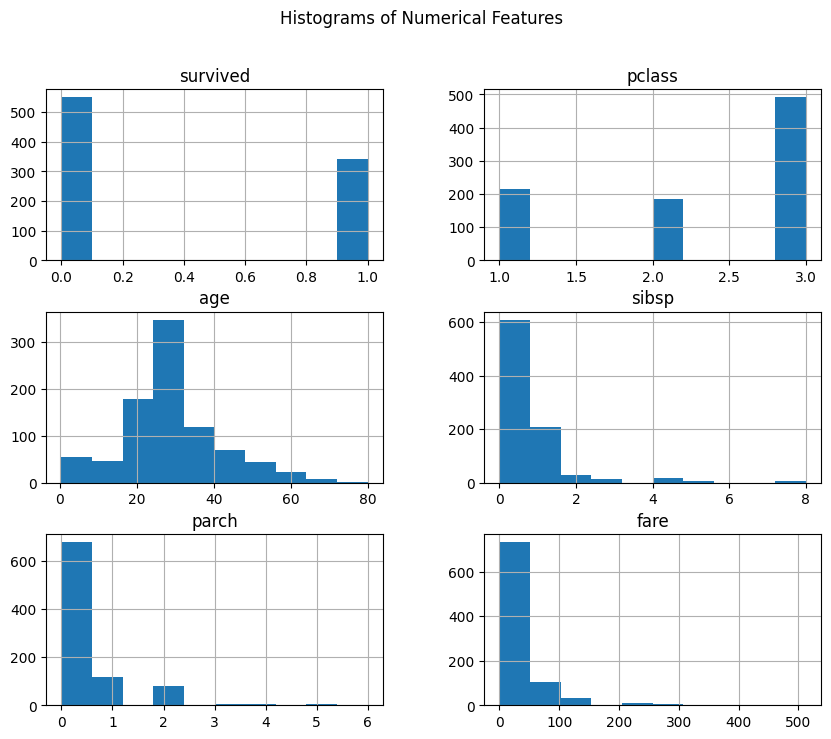

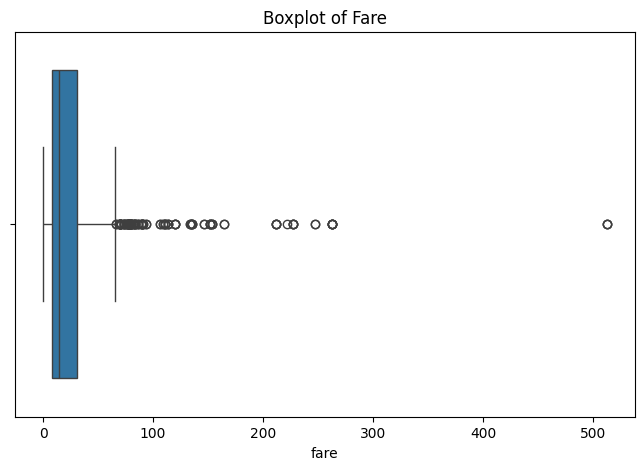

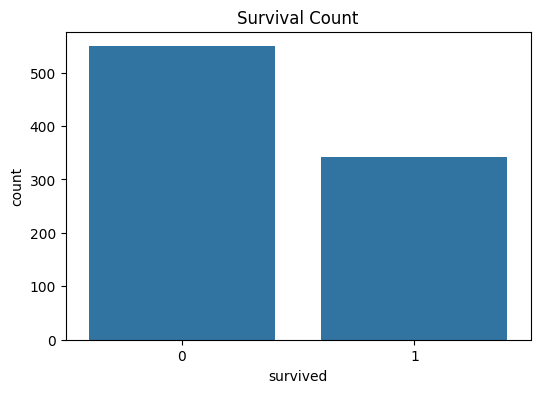

In [26]:
# Step 8: Visualization
# Histogram
df.hist(figsize=(10,8))
plt.suptitle("Histograms of Numerical Features")
plt.show()
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare'])
plt.title("Boxplot of Fare")
plt.show()
# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

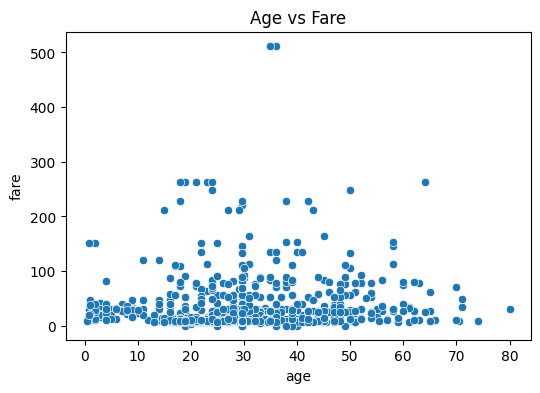

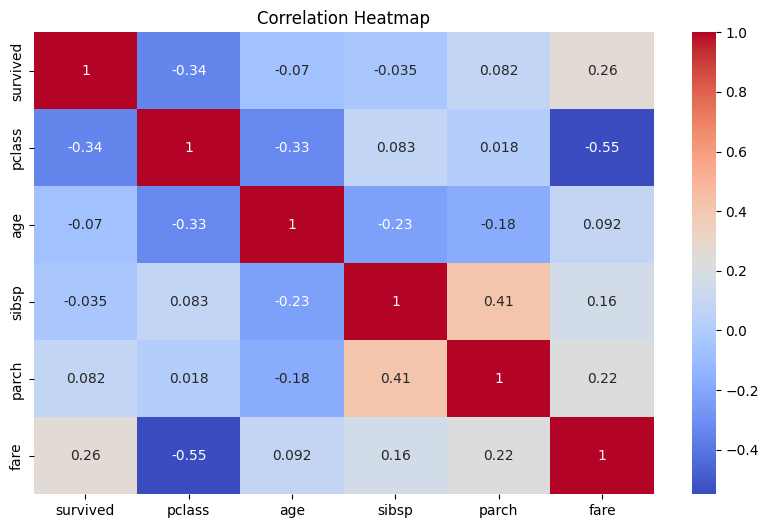

In [27]:
# Step 9: Bivariate Analysis
# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='fare', data=df)
plt.title("Age vs Fare")
plt.show()
# Correlation Heatmap
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [28]:
# Step 10: Group Analysis
print("\n----- Group Analysis (Mean Fare by Class) -----")
print(df.groupby('class')['fare'].mean())
print("\nEDA Completed Successfully")


----- Group Analysis (Mean Fare by Class) -----
class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64

EDA Completed Successfully
